# **Detection of Spammers and Fake Accounts on Social Media**


---

**Dataset:** 
**Link:** https://www.kaggle.com/datasets/free4ever1/instagram-fake-spammer-genuine-accounts  


**How to run in Google Colab:**
1. Upload your `kaggle.json` to `/content/` using the file panel on the left



## Kaggle Authentication and Dataset Download

In [1]:
import os, shutil, zipfile, json, glob

KAGGLE_JSON = "/content/kaggle.json"

if not os.path.exists(KAGGLE_JSON):
    raise FileNotFoundError(
        "kaggle.json not found at /content/kaggle.json\n"
        "Upload it using the file panel on the left sidebar."
    )

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
dest = os.path.join(kaggle_dir, "kaggle.json")
shutil.copy(KAGGLE_JSON, dest)
os.chmod(dest, 0o600)

with open(dest) as f:
    creds = json.load(f)
print("Authenticated as:", creds.get("username"))

os.system("pip install -q kaggle")

DOWNLOAD_DIR = "/content/insta_data"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.system(f"kaggle datasets download -d free4ever1/instagram-fake-spammer-genuine-accounts -p {DOWNLOAD_DIR} --force")

for zf in glob.glob(os.path.join(DOWNLOAD_DIR, "*.zip")):
    with zipfile.ZipFile(zf) as z:
        z.extractall(DOWNLOAD_DIR)
    os.remove(zf)

DATA_DIR = DOWNLOAD_DIR
print("Files downloaded:")
for f in glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True):
    print(" ", f)


Authenticated as: naveenvekkudu
Files downloaded:
  /content/insta_data/test.csv
  /content/insta_data/train.csv


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings, os, json
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "text.color": "#e6edf3", "grid.color": "#21262d", "grid.alpha": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

C = {
    "fake": "#ff6b6b", "genuine": "#51cf66", "blue": "#339af0",
    "purple": "#cc5de8", "yellow": "#ffd43b", "orange": "#fd7e14",
}


## Load Dataset

In [3]:
if "DATA_DIR" not in dir():
    DATA_DIR = "/kaggle/input/instagram-fake-spammer-genuine-accounts"

train_files = glob.glob(os.path.join(DATA_DIR, "**", "train.csv"), recursive=True)
test_files  = glob.glob(os.path.join(DATA_DIR, "**", "test.csv"),  recursive=True)

df_train = pd.read_csv(train_files[0])
df_test  = pd.read_csv(test_files[0])
df = pd.concat([df_train, df_test], ignore_index=True)

FEATURES = [
    "profile pic", "nums/length username", "fullname words",
    "nums/length fullname", "name==username", "description length",
    "external URL", "private", "#posts", "#followers", "#follows"
]
BINARY_FEATS     = ["profile pic", "name==username", "external URL", "private"]
CONTINUOUS_FEATS = ["nums/length username", "fullname words", "nums/length fullname",
                    "description length", "#posts", "#followers", "#follows"]
TARGET = "fake"

print("Train:", df_train.shape, "  Test:", df_test.shape, "  Total:", df.shape)
print("Genuine:", (df[TARGET]==0).sum(), "  Fake:", (df[TARGET]==1).sum())
df.head()


Train: (576, 12)   Test: (120, 12)   Total: (696, 12)
Genuine: 348   Fake: 348


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


## Exploratory Data Analysis

### Dataset Audit

In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
display(df[CONTINUOUS_FEATS + [TARGET]].describe().T.round(3))

print("\nSkewness per continuous feature:")
for f in CONTINUOUS_FEATS:
    sk = df[f].skew()
    tag = "right-skewed" if sk > 1 else ("left-skewed" if sk < -1 else "normal")
    print(f"  {f:<30}  {sk:+.3f}  ({tag})")


Shape: (696, 12)

Missing values:
profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
nums/length username,696.0,0.167,0.219,0.0,0.0,0.0,0.33,0.92
fullname words,696.0,1.476,1.077,0.0,1.0,1.0,2.00,12.00
nums/length fullname,696.0,0.042,0.144,0.0,0.0,0.0,0.00,1.00
description length,696.0,23.412,38.596,0.0,0.0,0.0,35.00,150.00
#posts,696.0,103.244,378.028,0.0,0.0,9.0,77.00,7389.00
#followers,696.0,79149.905,842887.538,0.0,42.0,165.5,693.00,15338538.00
#follows,696.0,555.086,1023.614,0.0,61.0,252.0,601.75,7500.00
fake,696.0,0.500,0.500,0.0,0.0,0.5,1.00,1.00



Skewness per continuous feature:
  nums/length username            +1.262  (right-skewed)
  fullname words                  +3.331  (right-skewed)
  nums/length fullname            +4.325  (right-skewed)
  description length              +1.802  (right-skewed)
  #posts                          +13.141  (right-skewed)
  #followers                      +14.411  (right-skewed)
  #follows                        +4.407  (right-skewed)


### Class Distribution

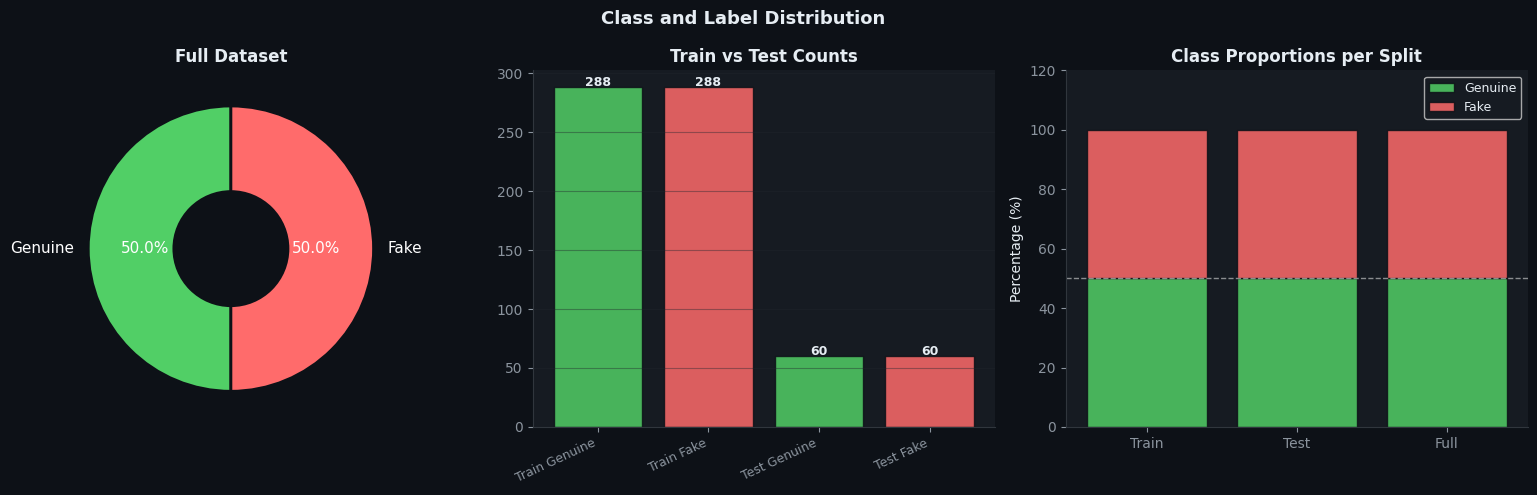

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Class and Label Distribution", fontsize=13, fontweight="bold")

counts = df[TARGET].value_counts()
axes[0].pie(counts, labels=["Genuine", "Fake"], colors=[C["genuine"], C["fake"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "#0d1117", "linewidth": 2, "width": 0.6},
            textprops={"color": "white", "fontsize": 11})
axes[0].set_title("Full Dataset", fontweight="bold")

split_counts = {
    "Train Genuine": (df_train[TARGET]==0).sum(), "Train Fake": (df_train[TARGET]==1).sum(),
    "Test Genuine":  (df_test[TARGET]==0).sum(),  "Test Fake":  (df_test[TARGET]==1).sum(),
}
colors_bar = [C["genuine"], C["fake"], C["genuine"], C["fake"]]
bars = axes[1].bar(list(split_counts.keys()), list(split_counts.values()),
                   color=colors_bar, alpha=0.85, edgecolor="#0d1117")
axes[1].set_xticks(range(len(split_counts)))
axes[1].set_xticklabels(list(split_counts.keys()), rotation=25, ha="right", fontsize=9)
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 str(int(b.get_height())), ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Train vs Test Counts", fontweight="bold")
axes[1].grid(axis="y", alpha=0.4)

genuine_pcts = [(df_train[TARGET]==0).mean()*100, (df_test[TARGET]==0).mean()*100, (df[TARGET]==0).mean()*100]
fake_pcts    = [100 - p for p in genuine_pcts]
x = np.arange(3)
axes[2].bar(x, genuine_pcts, color=C["genuine"], alpha=0.85, label="Genuine", edgecolor="#0d1117")
axes[2].bar(x, fake_pcts, color=C["fake"], alpha=0.85, label="Fake",
            bottom=genuine_pcts, edgecolor="#0d1117")
axes[2].set_xticks(x); axes[2].set_xticklabels(["Train", "Test", "Full"])
axes[2].set_ylabel("Percentage (%)"); axes[2].set_ylim(0, 120)
axes[2].axhline(50, color="white", ls="--", lw=1, alpha=0.5)
axes[2].set_title("Class Proportions per Split", fontweight="bold")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


### Univariate Feature Distributions

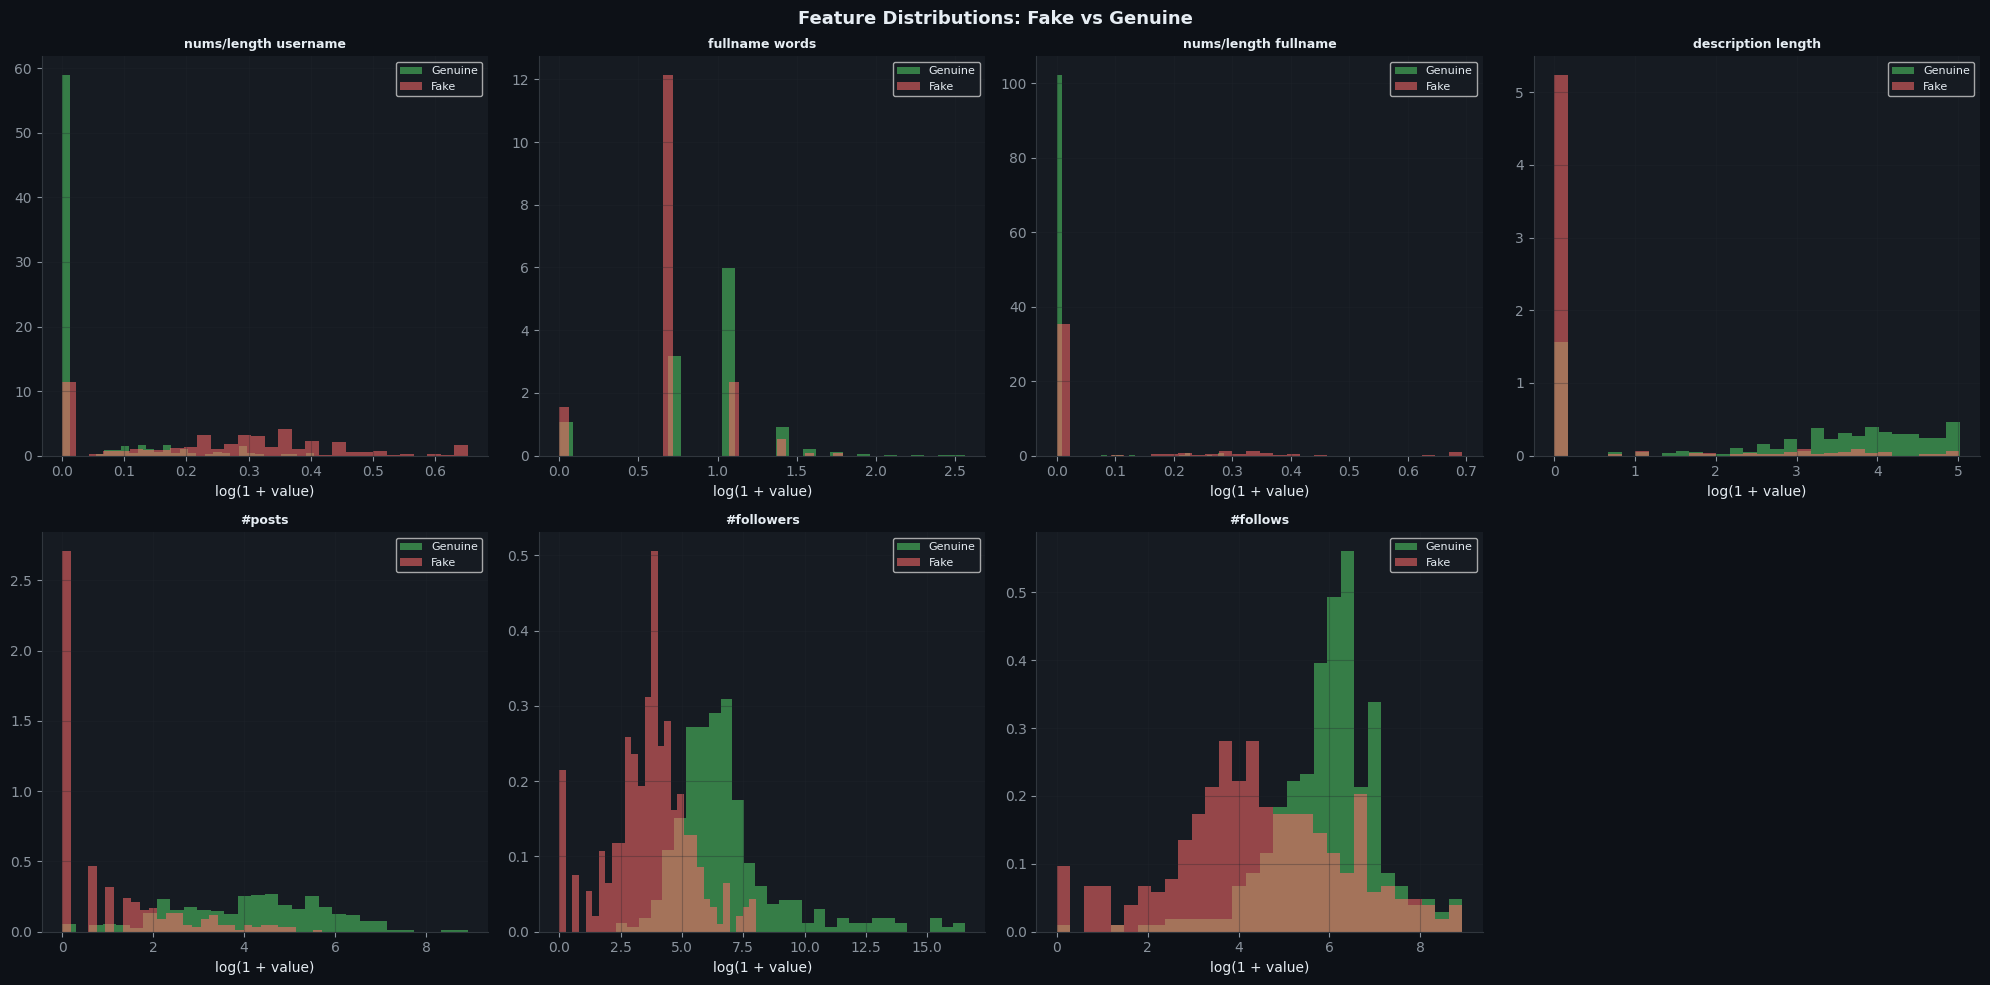

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Feature Distributions: Fake vs Genuine", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(CONTINUOUS_FEATS):
    for cls, color, label in [(0, C["genuine"], "Genuine"), (1, C["fake"], "Fake")]:
        axes[i].hist(np.log1p(df[df[TARGET]==cls][feat]), bins=30,
                     alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("log(1 + value)"); axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


### Box Plots and Outlier Analysis

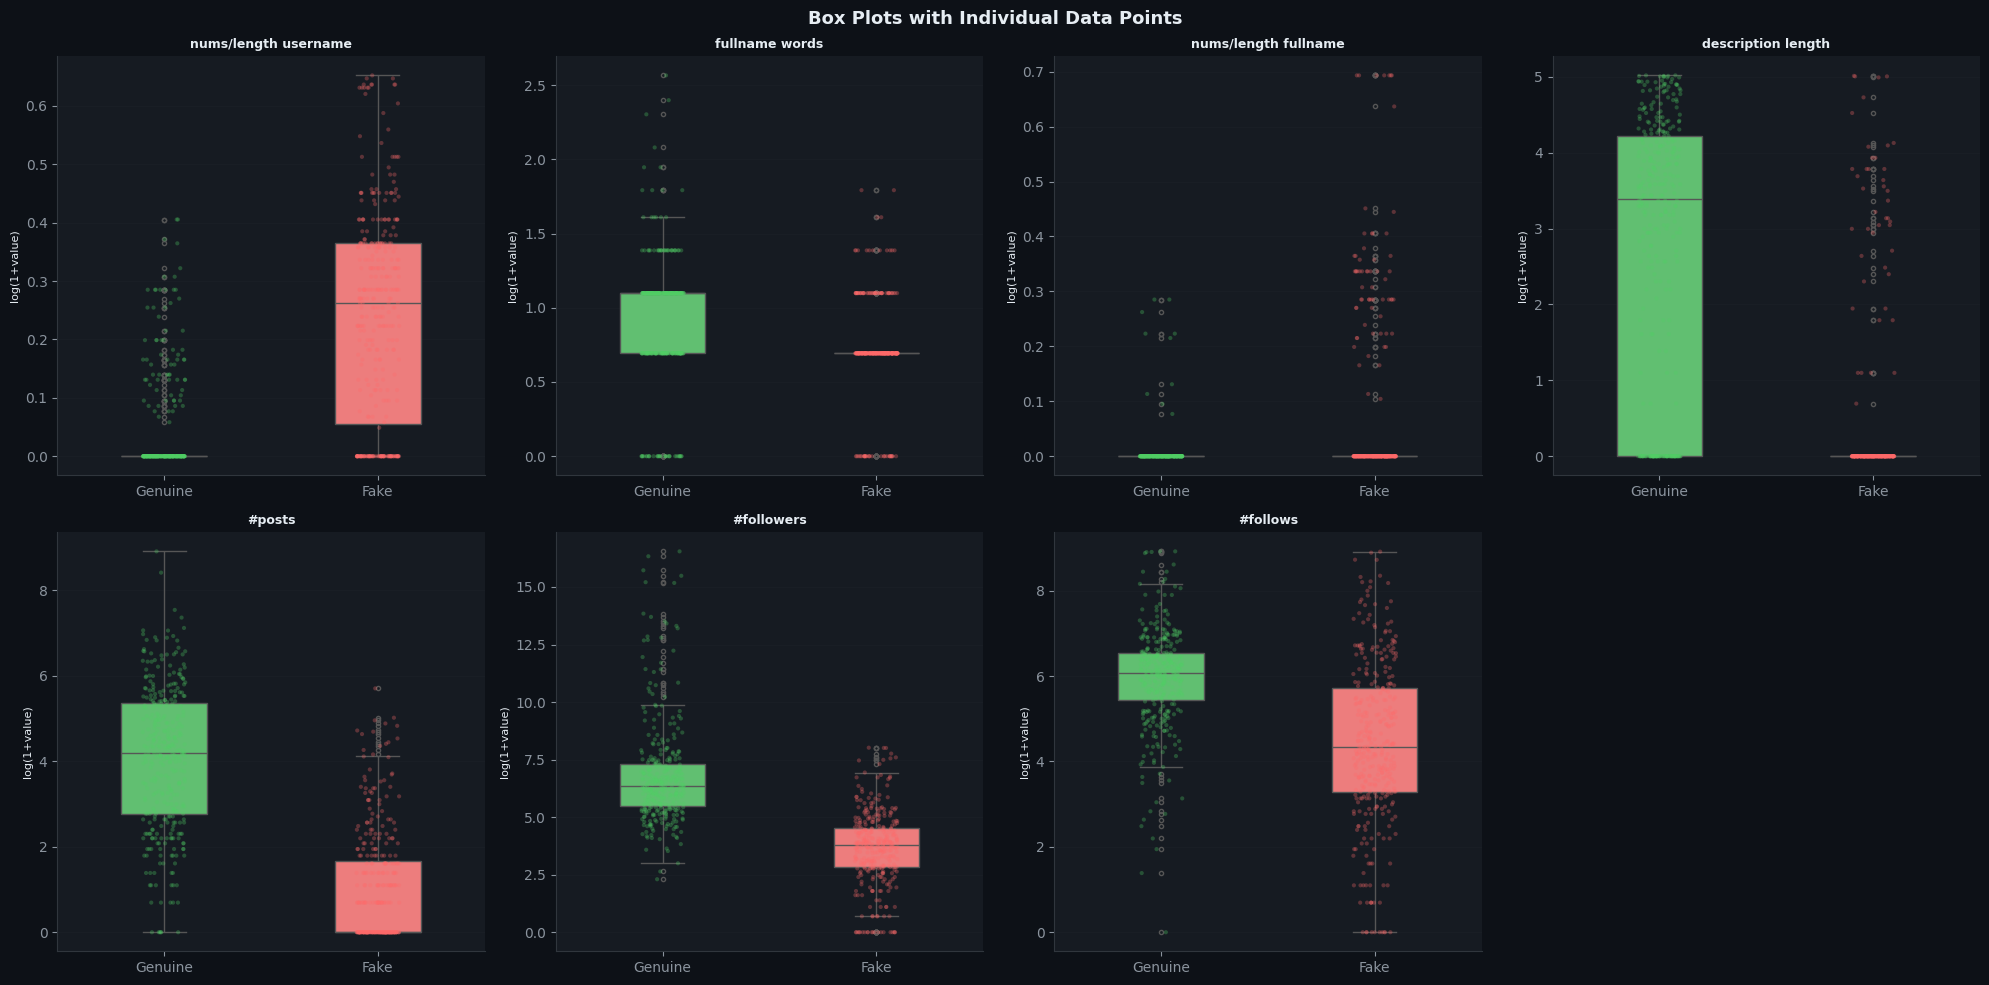

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Box Plots with Individual Data Points", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(CONTINUOUS_FEATS):
    plot_df = df[[TARGET, feat]].copy()
    plot_df["log_val"] = np.log1p(plot_df[feat])
    plot_df["class"]   = plot_df[TARGET].map({0: "Genuine", 1: "Fake"})
    sns.boxplot(x="class", y="log_val", data=plot_df, ax=axes[i],
                palette={"Genuine": C["genuine"], "Fake": C["fake"]},
                width=0.4, fliersize=3)
    sns.stripplot(x="class", y="log_val", data=plot_df, ax=axes[i],
                  palette={"Genuine": C["genuine"], "Fake": C["fake"]},
                  alpha=0.3, size=3, jitter=True)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xlabel(""); axes[i].set_ylabel("log(1+value)", fontsize=8)
    axes[i].grid(axis="y", alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


### Correlation Analysis

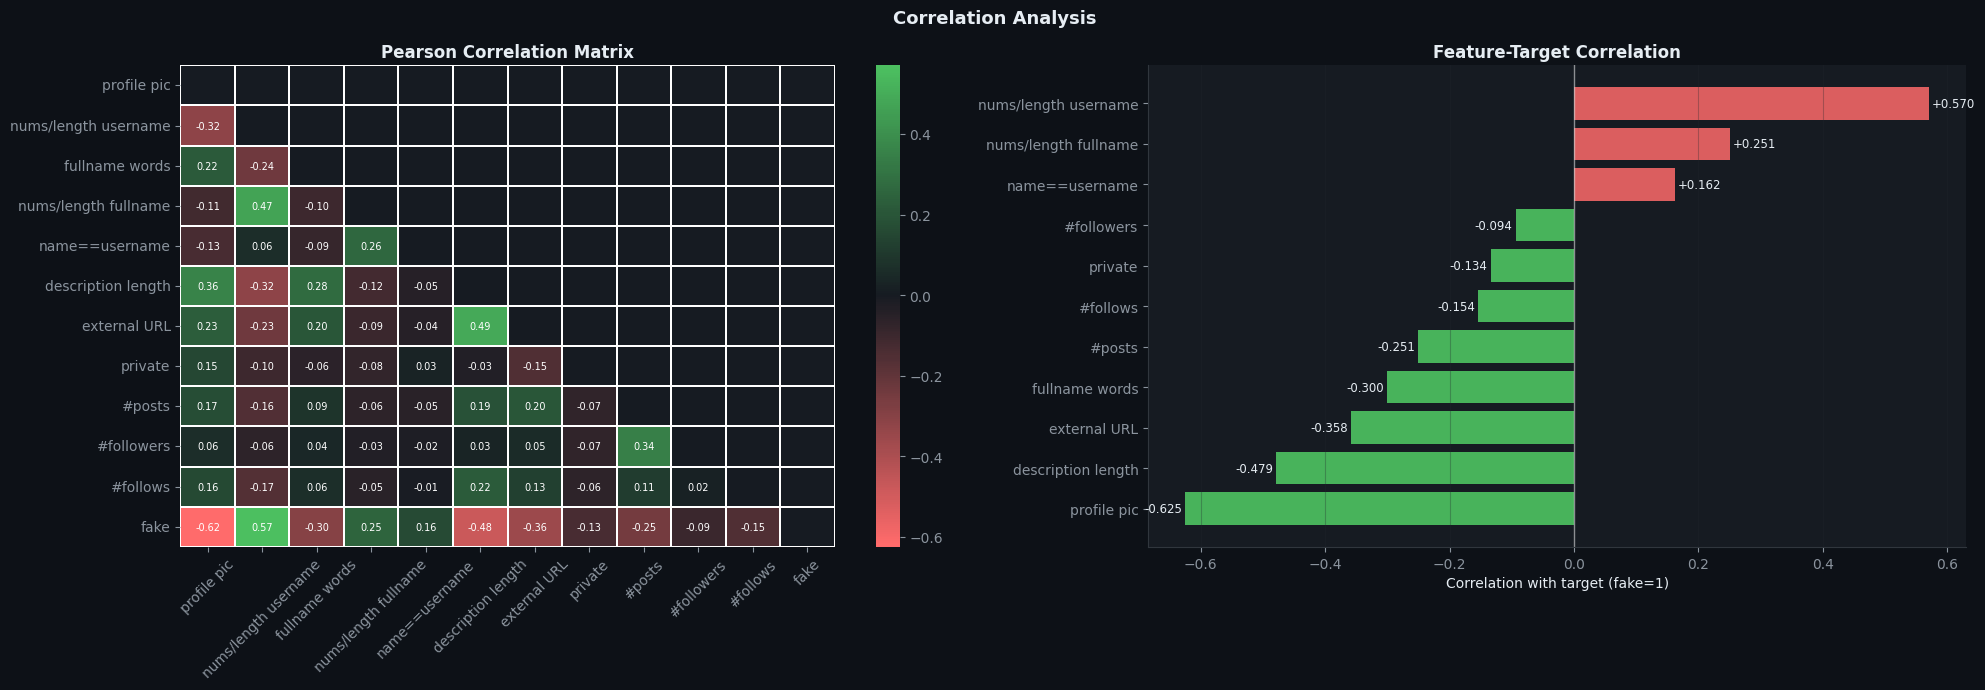

Top correlated features with fake label:
profile pic             0.624548
nums/length username    0.570363
description length      0.478890
external URL            0.357825


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Correlation Analysis", fontsize=13, fontweight="bold")

corr = df[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = LinearSegmentedColormap.from_list("cmap", ["#ff6b6b", "#161b22", "#51cf66"])
sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt=".2f",
            cmap=cmap, center=0, linewidths=0.3, annot_kws={"size": 7})
axes[0].set_title("Pearson Correlation Matrix", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

target_corr = df[FEATURES].corrwith(df[TARGET]).sort_values()
bar_colors  = [C["fake"] if v > 0 else C["genuine"] for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors, alpha=0.85)
for val, name in zip(target_corr.values, target_corr.index):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), name, f"{val:+.3f}",
                 va="center", ha="left" if val >= 0 else "right", fontsize=8.5)
axes[1].axvline(0, color="white", lw=1, alpha=0.5)
axes[1].set_xlabel("Correlation with target (fake=1)")
axes[1].set_title("Feature-Target Correlation", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
print("Top correlated features with fake label:")
print(target_corr.abs().nlargest(4).to_string())


### Violin Plots — Density Shape per Class

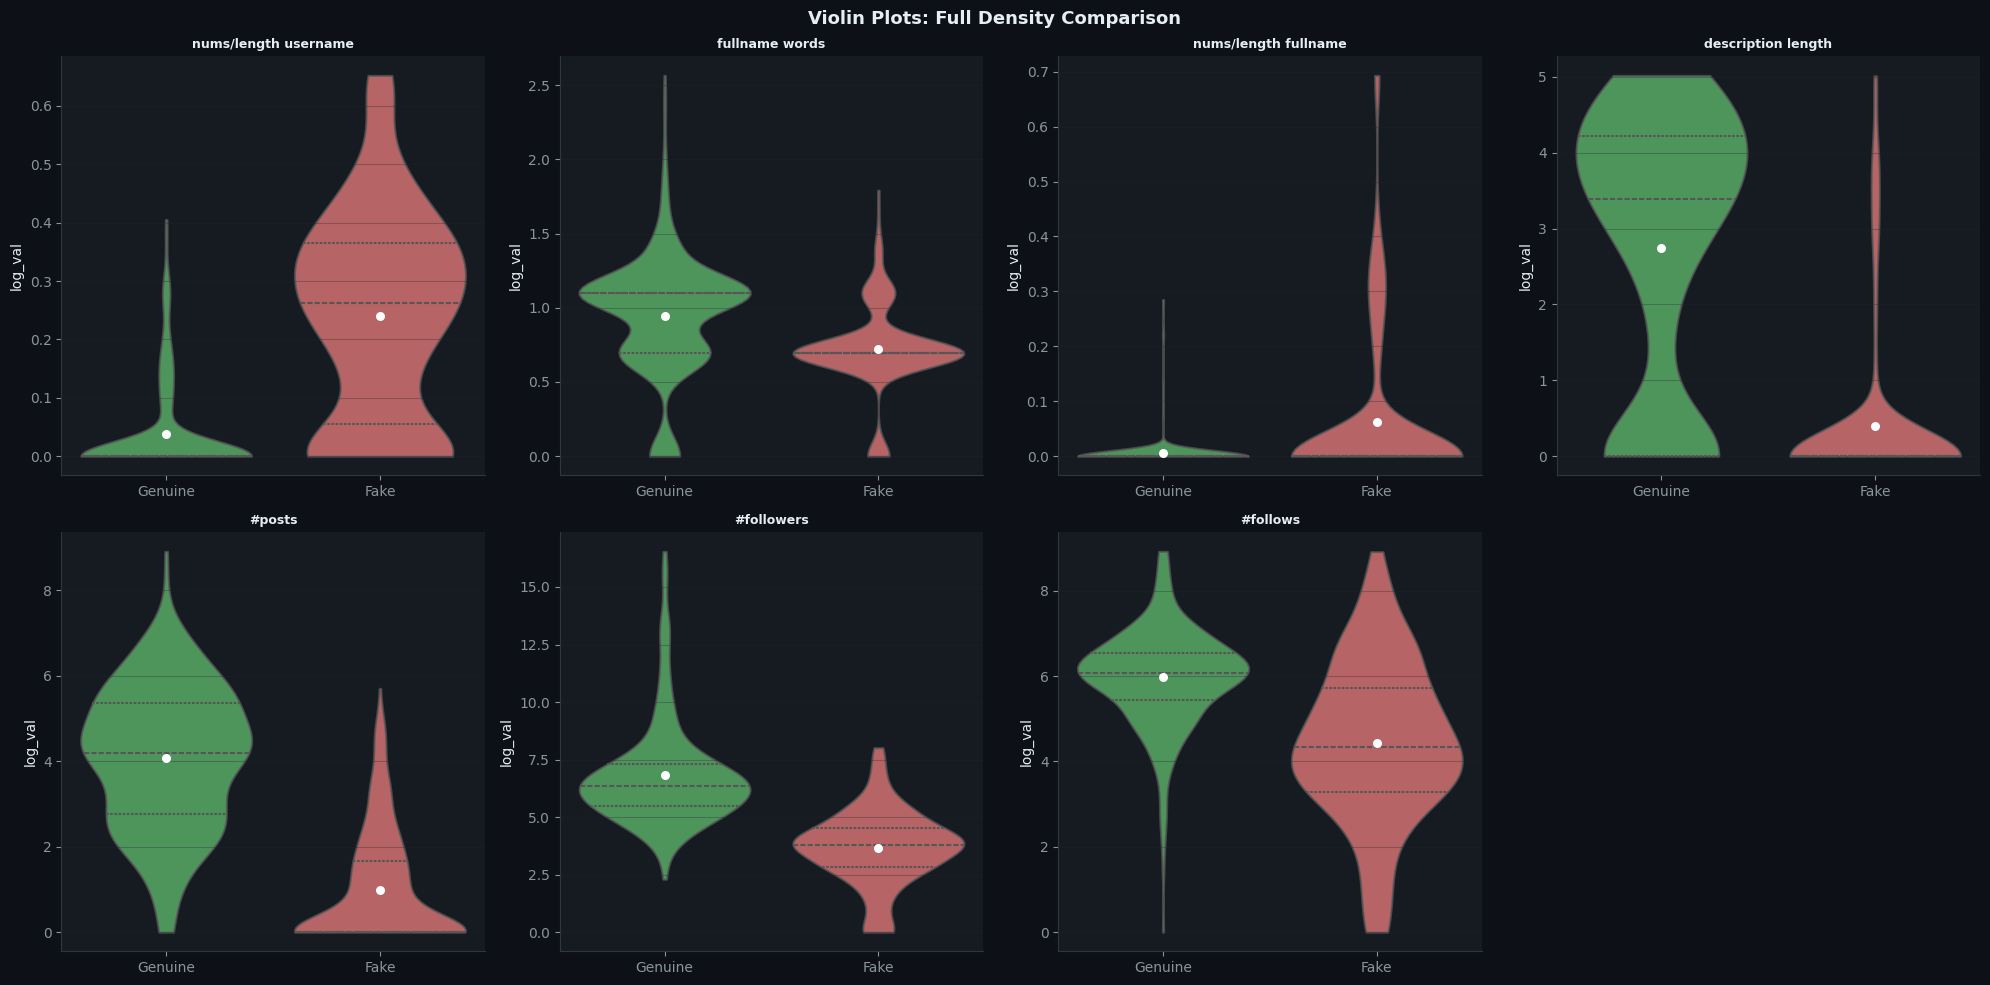

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Violin Plots: Full Density Comparison", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(CONTINUOUS_FEATS):
    plot_df = df[[TARGET, feat]].copy()
    plot_df["log_val"] = np.log1p(plot_df[feat])
    plot_df["class"]   = plot_df[TARGET].map({0: "Genuine", 1: "Fake"})
    sns.violinplot(x="class", y="log_val", data=plot_df, ax=axes[i],
                   palette={"Genuine": C["genuine"], "Fake": C["fake"]},
                   inner="quartile", cut=0, linewidth=1.5, alpha=0.75)
    for j, cls_label in enumerate(["Genuine", "Fake"]):
        mean_v = plot_df[plot_df["class"]==cls_label]["log_val"].mean()
        axes[i].scatter(j, mean_v, color="white", s=30, zorder=5)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xlabel(""); axes[i].grid(axis="y", alpha=0.3)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


### Chi-Square Test on Binary Features

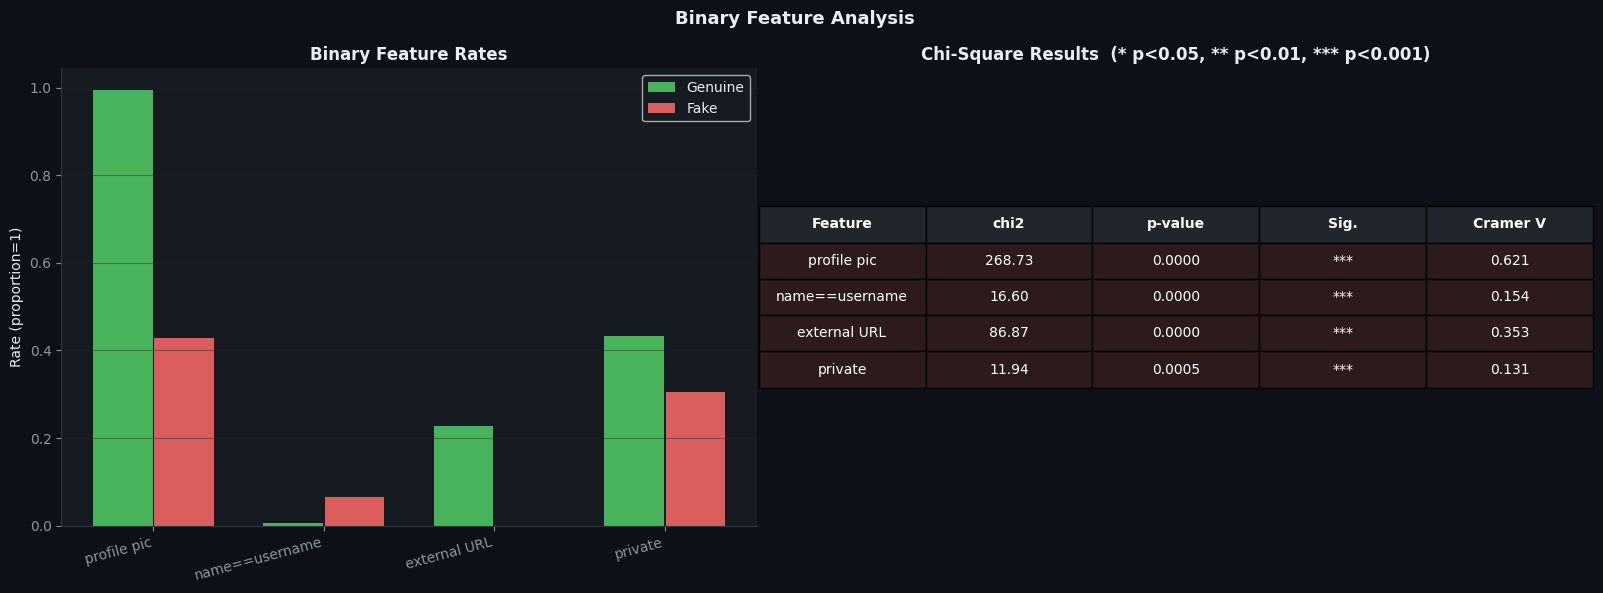

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Binary Feature Analysis", fontsize=13, fontweight="bold")

rates_g = df[df[TARGET]==0][BINARY_FEATS].mean()
rates_f = df[df[TARGET]==1][BINARY_FEATS].mean()
x = np.arange(len(BINARY_FEATS))
axes[0].bar(x - 0.18, rates_g, 0.35, label="Genuine", color=C["genuine"], alpha=0.85)
axes[0].bar(x + 0.18, rates_f, 0.35, label="Fake",    color=C["fake"],    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(BINARY_FEATS, rotation=15, ha="right")
axes[0].set_ylabel("Rate (proportion=1)"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.4)
axes[0].set_title("Binary Feature Rates", fontweight="bold")

axes[1].axis("off")
rows = []
for feat in BINARY_FEATS:
    ct = pd.crosstab(df[TARGET], df[feat])
    chi2, p, _, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / len(df))
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    rows.append([feat, f"{chi2:.2f}", f"{p:.4f}", sig, f"{v:.3f}"])

table = axes[1].table(cellText=rows,
                      colLabels=["Feature", "chi2", "p-value", "Sig.", "Cramer V"],
                      loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 2.2)
for j in range(5):
    table[0, j].set_facecolor("#21262d")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(len(rows)):
    bg = "#2d1a1a" if float(rows[i][2]) < 0.05 else "#1a2d1a"
    for j in range(5):
        table[i+1, j].set_facecolor(bg)
        table[i+1, j].set_text_props(color="white")
axes[1].set_title("Chi-Square Results  (* p<0.05, ** p<0.01, *** p<0.001)", fontweight="bold")

plt.tight_layout()
plt.show()


### Statistical Significance Tests

Feature                           t-stat   p(t-test)      p(MWU)   |r_pb|  Sig
--------------------------------------------------------------------------------
  nums/length username            -18.29      0.0000      0.0000    0.570  ***
  fullname words                   +8.30      0.0000      0.0000    0.300  ***
  nums/length fullname             -6.83      0.0000      0.0000    0.251  ***
  description length              +14.37      0.0000      0.0000    0.479  ***
  #posts                           +6.82      0.0000      0.0000    0.251  ***
  #followers                       +2.48      0.0133      0.0000    0.094  ***
  #follows                         +4.11      0.0000      0.0000    0.154  ***


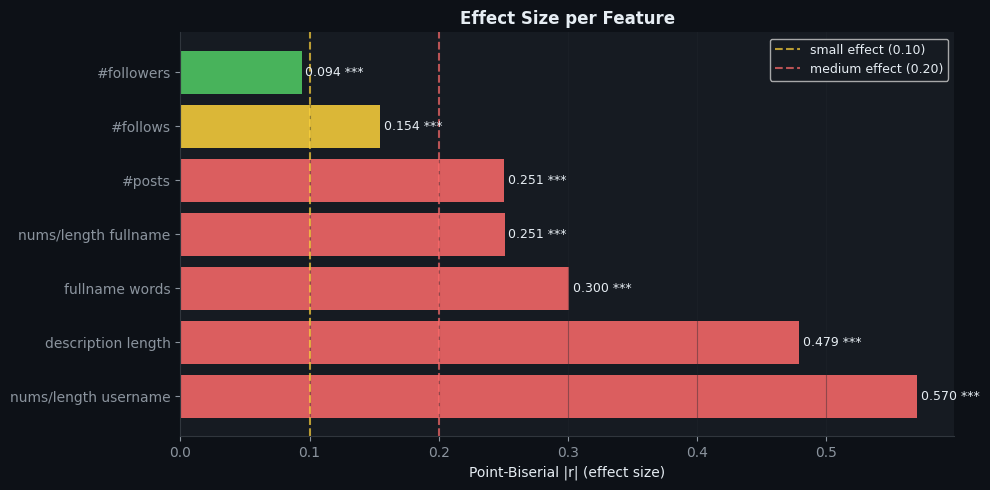

In [11]:
print(f"{'Feature':<30}  {'t-stat':>8}  {'p(t-test)':>10}  {'p(MWU)':>10}  {'|r_pb|':>7}  Sig")
print("-" * 80)

rows = []
for feat in CONTINUOUS_FEATS:
    g = df[df[TARGET]==0][feat].dropna()
    f = df[df[TARGET]==1][feat].dropna()
    t_stat, t_p = ttest_ind(g, f)
    _, u_p       = mannwhitneyu(g, f, alternative="two-sided")
    r_pb, _      = pointbiserialr(df[TARGET], df[feat])
    p_min        = min(t_p, u_p)
    sig = "***" if p_min < 0.001 else ("**" if p_min < 0.01 else ("*" if p_min < 0.05 else "ns"))
    print(f"  {feat:<28}  {t_stat:>+8.2f}  {t_p:>10.4f}  {u_p:>10.4f}  {abs(r_pb):>7.3f}  {sig}")
    rows.append((feat, abs(r_pb), sig))

rows_sorted = sorted(rows, key=lambda x: x[1], reverse=True)
fig, ax = plt.subplots(figsize=(10, 5))
names   = [r[0] for r in rows_sorted]
effects = [r[1] for r in rows_sorted]
colors_e = [C["fake"] if e > 0.2 else C["yellow"] if e > 0.1 else C["genuine"] for e in effects]
bars = ax.barh(names, effects, color=colors_e, alpha=0.85)
for bar, val, sig in zip(bars, effects, [r[2] for r in rows_sorted]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f} {sig}", va="center", fontsize=9)
ax.axvline(0.1, color=C["yellow"], ls="--", lw=1.5, alpha=0.7, label="small effect (0.10)")
ax.axvline(0.2, color=C["fake"],   ls="--", lw=1.5, alpha=0.7, label="medium effect (0.20)")
ax.set_xlabel("Point-Biserial |r| (effect size)")
ax.set_title("Effect Size per Feature", fontweight="bold", fontsize=12)
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()


### PCA and t-SNE — 2D Class Separability

Computing t-SNE ...


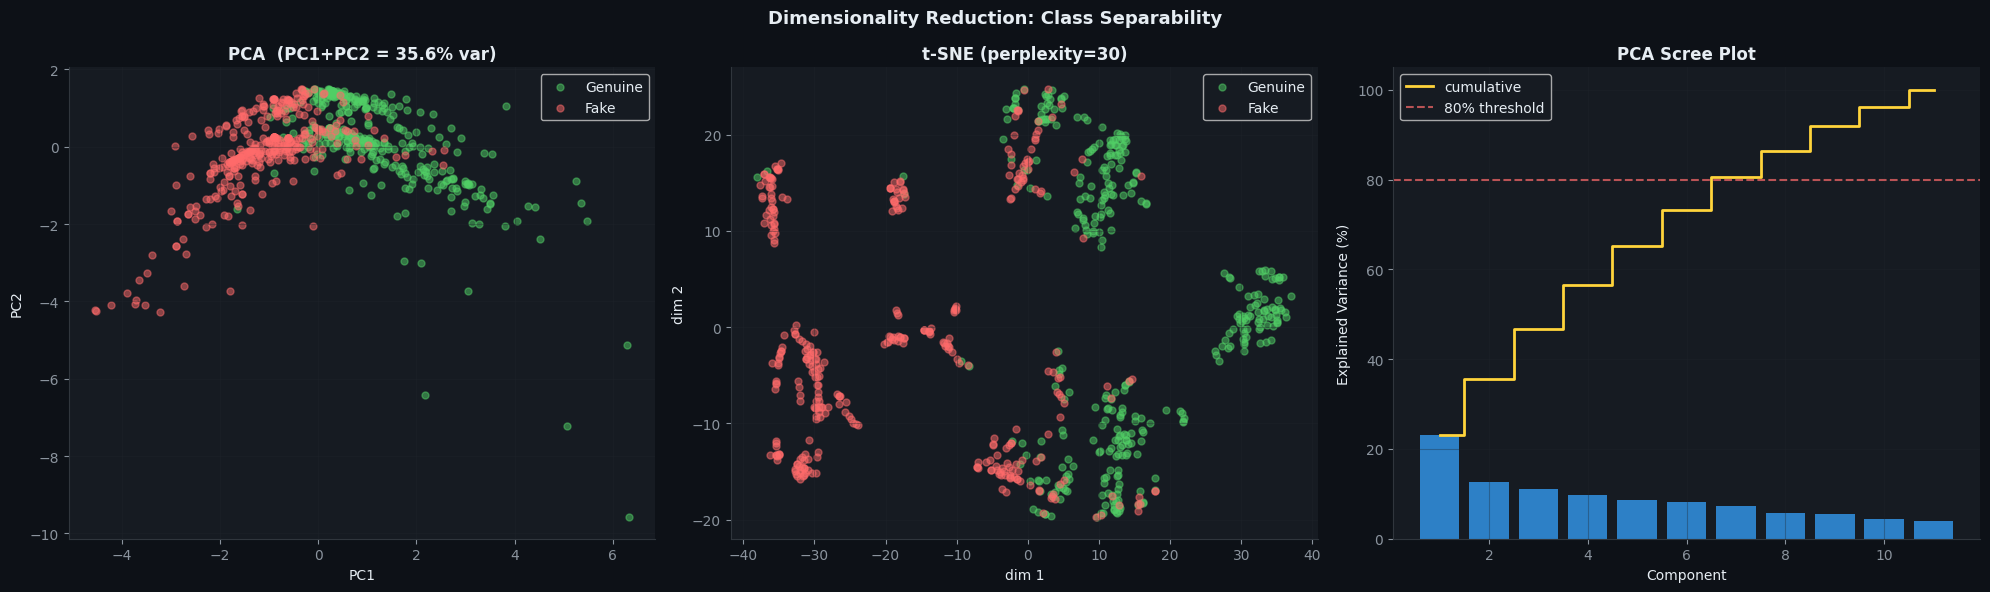

Components needed for 80% variance: 7


In [12]:
X_eda = df[FEATURES].fillna(0).values
y_eda = df[TARGET].values
from sklearn.preprocessing import StandardScaler
X_eda_s = StandardScaler().fit_transform(X_eda)

pca   = PCA(n_components=len(FEATURES), random_state=SEED)
X_pca = pca.fit_transform(X_eda_s)
pca2  = X_pca[:, :2]

print("Computing t-SNE ...")
X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000).fit_transform(X_eda_s)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Dimensionality Reduction: Class Separability", fontsize=13, fontweight="bold")

for cls, label, color in [(0, "Genuine", C["genuine"]), (1, "Fake", C["fake"])]:
    mask = y_eda == cls
    axes[0].scatter(pca2[mask, 0], pca2[mask, 1], c=color, label=label, alpha=0.5, s=25)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=label, alpha=0.5, s=25)

axes[0].set_title(f"PCA  (PC1+PC2 = {sum(pca.explained_variance_ratio_[:2])*100:.1f}% var)", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(); axes[0].grid(alpha=0.35)
axes[1].set_title("t-SNE (perplexity=30)", fontweight="bold")
axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2"); axes[1].legend(); axes[1].grid(alpha=0.35)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[2].bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_*100, color=C["blue"], alpha=0.8)
axes[2].step(range(1, len(cumvar)+1), cumvar, where="mid", color=C["yellow"], lw=2, label="cumulative")
axes[2].axhline(80, color=C["fake"], ls="--", lw=1.5, alpha=0.7, label="80% threshold")
axes[2].set_xlabel("Component"); axes[2].set_ylabel("Explained Variance (%)")
axes[2].set_title("PCA Scree Plot", fontweight="bold"); axes[2].legend(); axes[2].grid(alpha=0.35)

plt.tight_layout()
plt.show()

n80 = int(np.argmax(cumvar >= 80)) + 1
print(f"Components needed for 80% variance: {n80}")


### Fake Account Profile Fingerprinting

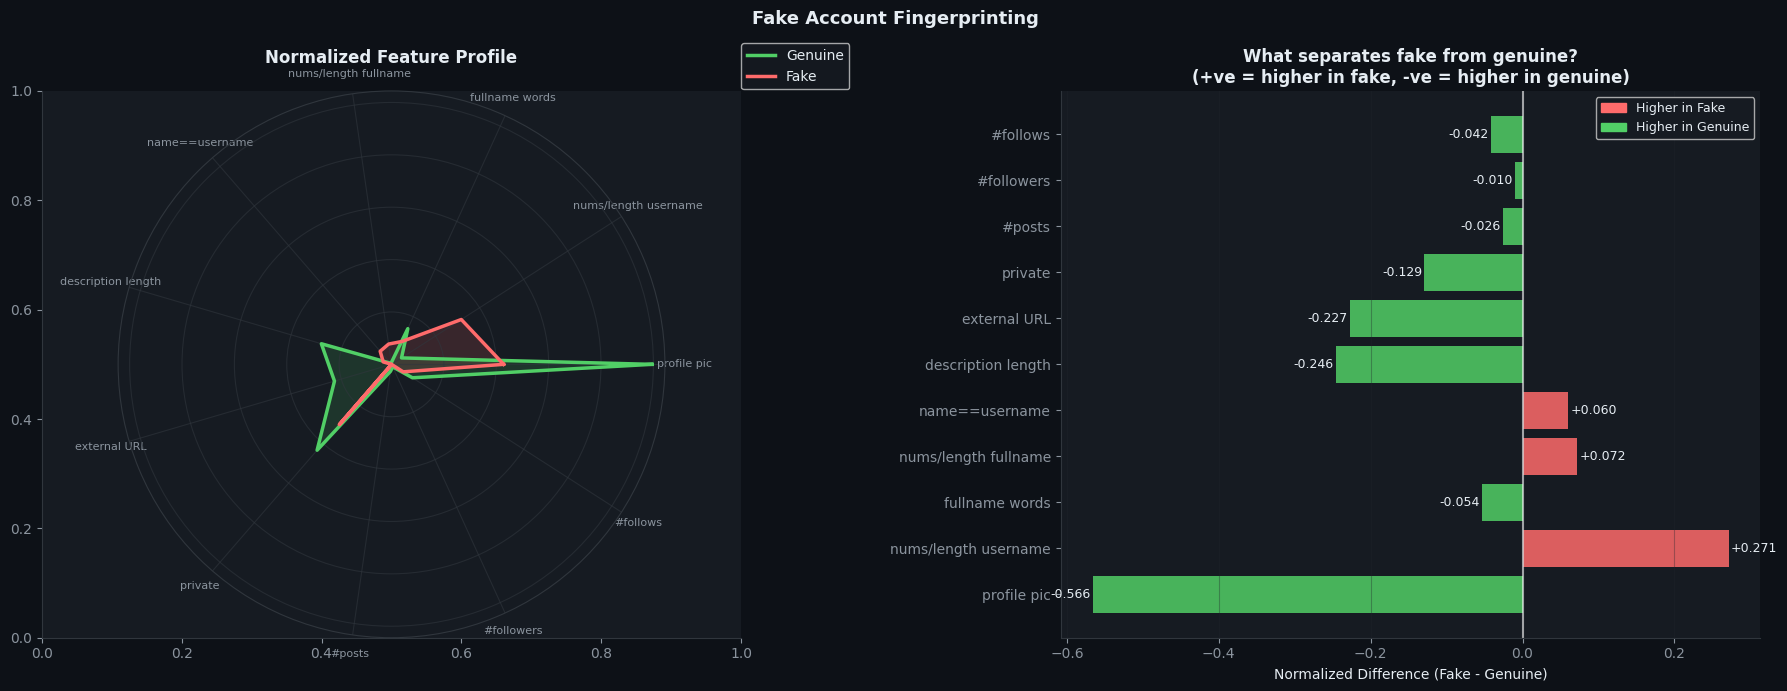

Top signals of fake accounts (normalized):
  nums/length username            +0.271  (higher in fake)
  nums/length fullname            +0.072  (higher in fake)
  name==username                  +0.060  (higher in fake)
  #followers                      -0.010  (higher in fake)
  profile pic                     -0.566  (higher in genuine)
  description length              -0.246  (higher in genuine)
  external URL                    -0.227  (higher in genuine)


In [13]:
df_norm = df[FEATURES + [TARGET]].copy()
for feat in FEATURES:
    mn, mx = df_norm[feat].min(), df_norm[feat].max()
    df_norm[feat] = (df_norm[feat] - mn) / (mx - mn) if mx > mn else 0.0

mean_genuine = df_norm[df_norm[TARGET]==0][FEATURES].mean().values
mean_fake    = df_norm[df_norm[TARGET]==1][FEATURES].mean().values
diff         = mean_fake - mean_genuine

N      = len(FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), subplot_kw={"polar": False})
fig.suptitle("Fake Account Fingerprinting", fontsize=13, fontweight="bold")

ax_r = plt.subplot(1, 2, 1, polar=True)
ax_r.set_facecolor("#161b22")
for vals, color, label in [(mean_genuine, C["genuine"], "Genuine"), (mean_fake, C["fake"], "Fake")]:
    v = vals.tolist() + [vals[0]]
    ax_r.plot(angles, v, lw=2.5, color=color, label=label)
    ax_r.fill(angles, v, alpha=0.15, color=color)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(FEATURES, size=8)
ax_r.set_yticklabels([]); ax_r.grid(color="#30363d", lw=0.8)
ax_r.set_title("Normalized Feature Profile", fontweight="bold", pad=20)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)

ax2 = plt.subplot(1, 2, 2)
diff_df = pd.Series(diff, index=FEATURES, name="diff (fake - genuine)")
colors_d = [C["fake"] if d > 0 else C["genuine"] for d in diff]
bars = ax2.barh(diff_df.index, diff_df.values, color=colors_d, alpha=0.85)
for bar, val in zip(bars, diff_df.values):
    ax2.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height()/2, f"{val:+.3f}",
             va="center", ha="left" if val >= 0 else "right", fontsize=9)
ax2.axvline(0, color="white", lw=1.5, alpha=0.6)
ax2.set_xlabel("Normalized Difference (Fake - Genuine)")
ax2.set_title("What separates fake from genuine?\n(+ve = higher in fake, -ve = higher in genuine)",
              fontweight="bold")
ax2.legend(handles=[mpatches.Patch(color=C["fake"], label="Higher in Fake"),
                    mpatches.Patch(color=C["genuine"], label="Higher in Genuine")], fontsize=9)
ax2.grid(axis="x", alpha=0.35)

plt.tight_layout()
plt.show()

print("Top signals of fake accounts (normalized):")
for feat, val in diff_df.nlargest(4).items():
    print(f"  {feat:<30}  {val:+.3f}  (higher in fake)")
for feat, val in diff_df.nsmallest(3).items():
    print(f"  {feat:<30}  {val:+.3f}  (higher in genuine)")


## Feature Engineering and Preprocessing

In [14]:
df_full = pd.concat([df_train, df_test], ignore_index=True)
df_full[FEATURES] = df_full[FEATURES].fillna(0)

df_eng = df_full[FEATURES].copy()
df_eng["follower_follow_ratio"] = df_eng["#followers"] / (df_eng["#follows"] + 1)
df_eng["post_per_follower"]     = df_eng["#posts"] / (df_eng["#followers"] + 1)
df_eng["username_num_density"]  = df_eng["nums/length username"] * df_eng["nums/length fullname"]
df_eng["log_posts"]             = np.log1p(df_eng["#posts"])
df_eng["log_followers"]         = np.log1p(df_eng["#followers"])
df_eng["log_follows"]           = np.log1p(df_eng["#follows"])

FEAT_ENG = FEATURES + [
    "follower_follow_ratio", "post_per_follower",
    "username_num_density", "log_posts", "log_followers", "log_follows"
]
N_FEAT = len(FEAT_ENG)

X_raw   = df_eng[FEAT_ENG].values.astype(np.float32)
y       = df_full[TARGET].values.astype(np.float32)
scaler  = RobustScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
X_seq    = X_scaled.reshape(-1, N_FEAT, 1)

idx = np.arange(len(y))
tr_idx, tmp   = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y)
val_idx, te_idx = train_test_split(tmp, test_size=0.50, random_state=SEED, stratify=y[tmp])

X_tr,  X_val,  X_te  = X_seq[tr_idx], X_seq[val_idx], X_seq[te_idx]
y_tr,  y_val,  y_te  = y[tr_idx],     y[val_idx],     y[te_idx]

print(f"Features: {len(FEATURES)} raw + 6 engineered = {N_FEAT} total")
print(f"Train: {len(y_tr)}  Val: {len(y_val)}  Test: {len(y_te)}")

CB = [
    EarlyStopping(patience=12, restore_best_weights=True, monitor="val_auc", mode="max"),
    ReduceLROnPlateau(patience=5, factor=0.4, monitor="val_auc", mode="max", min_lr=1e-6)
]


Features: 11 raw + 6 engineered = 17 total
Train: 487  Val: 104  Test: 105


## **Bidirectional LSTM**

In [15]:
def build_bilstm(n_feat):
    inp = Input(shape=(n_feat, 1))
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = Model(inp, out, name="BiLSTM")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m

lstm_model = build_bilstm(N_FEAT)
lstm_model.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 17, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,249 (301.75 KB)

 Trainable params: 77,185 (301.50 KB)

 Non-trainable params: 64 (256.00 B)

In [16]:
lstm_hist = lstm_model.fit(
    X_tr, y_tr, validation_data=(X_val, y_val),
    epochs=100, batch_size=32, callbacks=CB
)
lstm_proba = lstm_model.predict(X_te, verbose=0).flatten()
lstm_preds = (lstm_proba >= 0.5).astype(int)
print("BiLSTM Test Report:")
print(classification_report(y_te, lstm_preds, target_names=["Genuine", "Fake"]))
print("AUC-ROC:", round(roc_auc_score(y_te, lstm_proba), 4))


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.7844 - auc: 0.8692 - loss: 0.4594 - precision: 0.7769 - recall: 0.7992 - val_accuracy: 0.7596 - val_auc: 0.8730 - val_loss: 0.6305 - val_precision: 0.9091 - val_recall: 0.5769 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8275 - auc: 0.9059 - loss: 0.3808 - precision: 0.8540 - recall: 0.7910 - val_accuracy: 0.7981 - val_auc: 0.8820 - val_loss: 0.6058 - val_precision: 0.8974 - val_recall: 0.6731 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8501 - auc: 0.9198 - loss: 0.3543 - precision: 0.8701 - recall: 0.8238 - val_accuracy: 0.7981 - val_auc: 0.8907 - val_loss: 0.5979 - val_precision: 0.8780 - val_recall: 0.6923 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8419 - auc: 0.9245 - loss: 0.3437 - precision: 0.8584 - recall: 0.8197 - val_accuracy: 0.7885 - val_auc: 0.9007 - val_loss: 0.5795 - va

##  **Multi-Scale 1D-CNN**

In [17]:
def build_cnn(n_feat):
    inp = Input(shape=(n_feat, 1))
    outs = []
    for k in [2, 3, 4, 5]:
        c = layers.Conv1D(64, k, activation="relu", padding="same")(inp)
        c = layers.BatchNormalization()(c)
        outs.append(layers.GlobalMaxPooling1D()(c))
    x = layers.Concatenate()(outs)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = Model(inp, out, name="MultiScale_CNN")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m

cnn_model = build_cnn(N_FEAT)
cnn_model.summary()


Model: "MultiScale_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 17, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 17, 64)    │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 17, 64)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 17, 64)    │        320 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 17, 64)    │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 43,905 (171.50 KB)

 Trainable params: 43,137 (168.50 KB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
cnn_hist = cnn_model.fit(
    X_tr, y_tr, validation_data=(X_val, y_val),
    epochs=100, batch_size=32, callbacks=CB
)
cnn_proba = cnn_model.predict(X_te, verbose=0).flatten()
cnn_preds = (cnn_proba >= 0.5).astype(int)
print("CNN Test Report:")
print(classification_report(y_te, cnn_preds, target_names=["Genuine", "Fake"]))
print("AUC-ROC:", round(roc_auc_score(y_te, cnn_proba), 4))


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7207 - auc: 0.7987 - loss: 0.5987 - precision: 0.8103 - recall: 0.5779 - val_accuracy: 0.7788 - val_auc: 0.8850 - val_loss: 0.6418 - val_precision: 0.8222 - val_recall: 0.7115 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8152 - auc: 0.8860 - loss: 0.4432 - precision: 0.8156 - recall: 0.8156 - val_accuracy: 0.7115 - val_auc: 0.8918 - val_loss: 0.6415 - val_precision: 0.8056 - val_recall: 0.5577 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8480 - auc: 0.8927 - loss: 0.4393 - precision: 0.8400 - recall: 0.8607 - val_accuracy: 0.7404 - val_auc: 0.8865 - val_loss: 0.6408 - val_precision: 0.8788 - val_recall: 0.5577 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8542 - auc: 0.9226 - loss: 0.3610 - precision: 0.8531 - recall: 0.8566 - val_accuracy: 0.5865 - val_auc: 0.8952 - val_loss: 0.6461 - val_

## **Transformer with Self-Attention**

In [19]:
class TransformerBlock(layers.Layer):
    def __init__(self, d, heads, ff, rate=0.1, **kw):
        super().__init__(**kw)
        self.attn = layers.MultiHeadAttention(num_heads=heads, key_dim=d)
        self.ffn  = keras.Sequential([layers.Dense(ff, activation="gelu"), layers.Dense(d)])
        self.ln1  = layers.LayerNormalization(epsilon=1e-6)
        self.ln2  = layers.LayerNormalization(epsilon=1e-6)
        self.d1   = layers.Dropout(rate)
        self.d2   = layers.Dropout(rate)

    def call(self, x, training=False):
        x = self.ln1(x + self.d1(self.attn(x, x), training=training))
        x = self.ln2(x + self.d2(self.ffn(x),     training=training))
        return x

def build_transformer(n_feat, d=32, heads=4, ff=64, blocks=2):
    inp = Input(shape=(n_feat, 1))
    x   = layers.Conv1D(d, 1, activation="relu")(inp)
    pos = layers.Embedding(n_feat, d)(tf.range(n_feat))
    x   = x + pos
    for _ in range(blocks):
        x = TransformerBlock(d, heads, ff)(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation="relu")(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = Model(inp, out, name="Transformer")
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m

trans_model = build_transformer(N_FEAT)
trans_model.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 17, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 17, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 17, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 17, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 17, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,393 (169.50 KB)

 Trainable params: 43,393 (169.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
trans_hist = trans_model.fit(
    X_tr, y_tr, validation_data=(X_val, y_val),
    epochs=100, batch_size=32, callbacks=CB
)
trans_proba = trans_model.predict(X_te, verbose=0).flatten()
trans_preds = (trans_proba >= 0.5).astype(int)
print("Transformer Test Report:")
print(classification_report(y_te, trans_preds, target_names=["Genuine", "Fake"]))
print("AUC-ROC:", round(roc_auc_score(y_te, trans_proba), 4))


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 771ms/step - accuracy: 0.7926 - auc: 0.8836 - loss: 0.4511 - precision: 0.8389 - recall: 0.7254 - val_accuracy: 0.8269 - val_auc: 0.9197 - val_loss: 0.3843 - val_precision: 0.8269 - val_recall: 0.8269 - learning_rate: 5.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8706 - auc: 0.9320 - loss: 0.3376 - precision: 0.9095 - recall: 0.8238 - val_accuracy: 0.8269 - val_auc: 0.9292 - val_loss: 0.3741 - val_precision: 0.8036 - val_recall: 0.8654 - learning_rate: 5.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8645 - auc: 0.9382 - loss: 0.3217 - precision: 0.8836 - recall: 0.8402 - val_accuracy: 0.8365 - val_auc: 0.9308 - val_loss: 0.3522 - val_precision: 0.8070 - val_recall: 0.8846 - learning_rate: 5.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8891 - auc: 0.9526 - loss: 0.2796 - precision: 0.8958 - recall: 0.8811 - val_accuracy: 0.8365 - val_auc: 0.9342 - val_loss

Transformer Test Report:
              precision    recall  f1-score   support

     Genuine       0.90      0.83      0.86        53
        Fake       0.84      0.90      0.87        52

    accuracy                           0.87       105
   macro avg       0.87      0.87      0.87       105
weighted avg       0.87      0.87      0.87       105

AUC-ROC: 0.9318


##  **Fine-Tuned Autoencoder Classifier**

**Fine-tuning strategy: 3-stage training**

- **Stage 1** Pre-train an autoencoder on all feature data without labels (unsupervised). The encoder learns compressed representations of Instagram profiles.
- **Stage 2a** Freeze the encoder. Attach and train a classification head only.
- **Stage 2b** Unfreeze all layers and fine-tune end-to-end with a very small learning rate.

This is analogous to BERT-style transfer learning applied to tabular data.


### Stage 1 — Unsupervised Autoencoder Pre-training

In [21]:
def build_encoder(n_feat, latent_dim=16):
    inp = Input(shape=(n_feat,))
    x = layers.Dense(64, activation="elu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="elu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)
    z = layers.Dense(latent_dim, activation="elu", name="latent")(x)
    return Model(inp, z, name="Encoder")

def build_decoder(latent_dim, n_feat):
    inp = Input(shape=(latent_dim,))
    x   = layers.Dense(32, activation="elu")(inp)
    x   = layers.Dense(64, activation="elu")(x)
    out = layers.Dense(n_feat, activation="linear")(x)
    return Model(inp, out, name="Decoder")

LATENT_DIM = 16
encoder = build_encoder(N_FEAT, LATENT_DIM)
decoder = build_decoder(LATENT_DIM, N_FEAT)

ae_inp   = Input(shape=(N_FEAT,))
ae_model = Model(ae_inp, decoder(encoder(ae_inp)), name="Autoencoder")
ae_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
encoder.summary()


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,144 (16.19 KB)

 Trainable params: 3,952 (15.44 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
# Train on ALL samples — no labels used
ae_hist = ae_model.fit(
    X_scaled, X_scaled,
    epochs=100, batch_size=32, validation_split=0.15,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
        ReduceLROnPlateau(patience=4, factor=0.5, monitor="val_loss", min_lr=1e-6)
    ]
)

recon_mse = np.mean((X_scaled - ae_model.predict(X_scaled, verbose=0))**2)
print(f"Reconstruction MSE on full dataset: {recon_mse:.6f}")


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - loss: 127449904.0000 - mae: 182.6359 - val_loss: 28219.2324 - val_mae: 8.0925 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 127447064.0000 - mae: 182.5814 - val_loss: 28163.8711 - val_mae: 8.0637 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 127444208.0000 - mae: 182.5506 - val_loss: 28135.4961 - val_mae: 8.0688 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 127441416.0000 - mae: 182.5466 - val_loss: 28112.6719 - val_mae: 8.0885 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 127436680.0000 - mae: 182.5472 - val_loss: 28099.0020 - val_mae: 8.1205 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 127428144.0000 - mae: 182.5869 - val_loss: 28092.2188 - val_mae: 8.1654 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 127

### Stage 2a — Classification Head Training (Encoder Frozen)

In [23]:
encoder.trainable = False

X_tr_flat  = X_scaled[tr_idx]
X_val_flat = X_scaled[val_idx]
X_te_flat  = X_scaled[te_idx]

cls_inp = Input(shape=(N_FEAT,))
h = encoder(cls_inp)
h = layers.Dense(32, activation="relu")(h)
h = layers.BatchNormalization()(h)
h = layers.Dropout(0.25)(h)
h = layers.Dense(1, activation="sigmoid")(h)

cls_model = Model(cls_inp, h, name="FrozenEncoder_Classifier")
cls_model.compile(optimizer=keras.optimizers.Adam(5e-3), loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])

head_hist = cls_model.fit(
    X_tr_flat, y_tr, validation_data=(X_val_flat, y_val),
    epochs=50, batch_size=32,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True, monitor="val_auc", mode="max")]
)

h_proba = cls_model.predict(X_te_flat, verbose=0).flatten()
print(f"Head-only AUC: {roc_auc_score(y_te, h_proba):.4f}")


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step - accuracy: 0.5257 - auc: 0.5521 - loss: 0.7826 - val_accuracy: 0.5577 - val_auc: 0.7755 - val_loss: 0.6679
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6263 - auc: 0.6750 - loss: 0.6648 - val_accuracy: 0.5577 - val_auc: 0.7962 - val_loss: 0.6825
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6530 - auc: 0.7083 - loss: 0.6292 - val_accuracy: 0.5769 - val_auc: 0.8341 - val_loss: 0.6515
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6427 - auc: 0.7048 - loss: 0.6164 - val_accuracy: 0.5865 - val_auc: 0.8354 - val_loss: 0.6446
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6756 - auc: 0.7438 - loss: 0.5960 - val_accuracy: 0.6346 - val_auc: 0.8267 - val_loss: 0.6337
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6940 - auc: 0.7400 - loss: 0.6069 - val_accuracy: 0.5192 - val_auc: 0.8630 - val_loss: 0.6442
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

### Stage 2b — Full Fine-Tuning (All Layers Unfrozen)

In [24]:
encoder.trainable = True

# Recompile with a much smaller learning rate to preserve pre-trained weights
cls_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])

finetune_hist = cls_model.fit(
    X_tr_flat, y_tr, validation_data=(X_val_flat, y_val),
    epochs=80, batch_size=16,
    callbacks=[
        EarlyStopping(patience=12, restore_best_weights=True, monitor="val_auc", mode="max"),
        ReduceLROnPlateau(patience=5, factor=0.5, monitor="val_auc", mode="max", min_lr=1e-7)
    ]
)

ae_proba = cls_model.predict(X_te_flat, verbose=0).flatten()
ae_preds = (ae_proba >= 0.5).astype(int)

print("Fine-Tuned Autoencoder Test Report:")
print(classification_report(y_te, ae_preds, target_names=["Genuine", "Fake"]))
print(f"AUC-ROC : {roc_auc_score(y_te, ae_proba):.4f}")
print(f"Improvement over head-only: {roc_auc_score(y_te, ae_proba) - roc_auc_score(y_te, h_proba):+.4f}")


Epoch 1/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.4333 - auc: 0.4393 - loss: 0.9828 - val_accuracy: 0.5000 - val_auc: 0.9251 - val_loss: 0.6208 - learning_rate: 1.0000e-05
Epoch 2/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4517 - auc: 0.4570 - loss: 0.9957 - val_accuracy: 0.5577 - val_auc: 0.9129 - val_loss: 0.6066 - learning_rate: 1.0000e-05
Epoch 3/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4723 - auc: 0.4729 - loss: 0.9443 - val_accuracy: 0.7692 - val_auc: 0.9003 - val_loss: 0.5924 - learning_rate: 1.0000e-05
Epoch 4/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4600 - auc: 0.4694 - loss: 0.9577 - val_accuracy: 0.8462 - val_auc: 0.9037 - val_loss: 0.5842 - learning_rate: 1.0000e-05
Epoch 5/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4928 - auc: 0.4680 - loss: 0.9806 - val_accuracy: 0.8365 - val_auc: 0.9059 - val_loss: 0.5790 - learning_rate: 1.0000e-05
Epoch 6/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.468

### Fine-Tuning Stage Performance

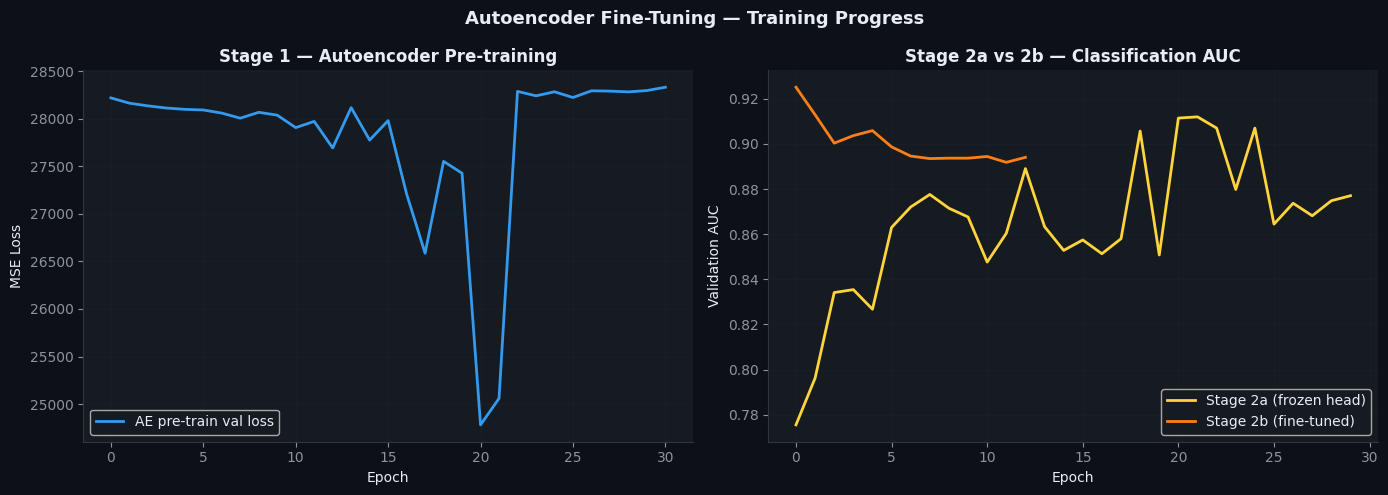

Stage 2a (head-only) final val AUC: 0.912
Stage 2b (fine-tuned) final val AUC: 0.9251


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Autoencoder Fine-Tuning — Training Progress", fontsize=13, fontweight="bold")

axes[0].plot(ae_hist.history["val_loss"], color=C["blue"], lw=2, label="AE pre-train val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Stage 1 — Autoencoder Pre-training", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.35)

axes[1].plot(head_hist.history["val_auc"],     color=C["yellow"], lw=2, label="Stage 2a (frozen head)")
axes[1].plot(finetune_hist.history["val_auc"], color=C["orange"], lw=2, label="Stage 2b (fine-tuned)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation AUC")
axes[1].set_title("Stage 2a vs 2b — Classification AUC", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.35)

plt.tight_layout()
plt.show()

print("Stage 2a (head-only) final val AUC:", round(max(head_hist.history["val_auc"]), 4))
print("Stage 2b (fine-tuned) final val AUC:", round(max(finetune_hist.history["val_auc"]), 4))


## Ensemble — Soft Voting (All 4 Models)

In [26]:
ens_proba = (lstm_proba + cnn_proba + trans_proba + ae_proba) / 4.0
ens_preds = (ens_proba >= 0.5).astype(int)

print("Ensemble Test Report:")
print(classification_report(y_te, ens_preds, target_names=["Genuine", "Fake"]))
print(f"AUC-ROC  : {roc_auc_score(y_te, ens_proba):.4f}")
print(f"Accuracy : {accuracy_score(y_te, ens_preds):.4f}")
print(f"F1-Score : {f1_score(y_te, ens_preds):.4f}")


Ensemble Test Report:
              precision    recall  f1-score   support

     Genuine       0.88      0.92      0.90        53
        Fake       0.92      0.87      0.89        52

    accuracy                           0.90       105
   macro avg       0.90      0.89      0.90       105
weighted avg       0.90      0.90      0.90       105

AUC-ROC  : 0.9702
Accuracy : 0.8952
F1-Score : 0.8911


## Model Evaluation and Comparison

In [27]:
ALL_MODELS = {
    "BiLSTM":      (lstm_proba,  lstm_preds,  lstm_hist),
    "1D-CNN":      (cnn_proba,   cnn_preds,   cnn_hist),
    "Transformer": (trans_proba, trans_preds, trans_hist),
    "Autoencoder": (ae_proba,    ae_preds,    finetune_hist),
    "Ensemble":    (ens_proba,   ens_preds,   None),
}
PAL = [C["blue"], C["fake"], C["purple"], C["orange"], C["yellow"]]

metrics = {}
for name, (proba, pred, _) in ALL_MODELS.items():
    fpr_r, tpr_r, _ = roc_curve(y_te, proba)
    prc_r, rec_r, _ = precision_recall_curve(y_te, proba)
    metrics[name] = {
        "Accuracy":  accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall":    recall_score(y_te, pred),
        "F1":        f1_score(y_te, pred),
        "AUC-ROC":   roc_auc_score(y_te, proba),
        "AUC-PR":    auc(rec_r, prc_r),
        "fpr": fpr_r, "tpr": tpr_r, "prc": prc_r, "rec_c": rec_r,
    }

summary_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ("fpr","tpr","prc","rec_c")}
    for name, vals in metrics.items()
}).T
print("Model Leaderboard:")
print(summary_df.to_string(float_format="{:.4f}".format))


Model Leaderboard:
             Accuracy  Precision  Recall     F1  AUC-ROC  AUC-PR
BiLSTM         0.9143     0.9388  0.8846 0.9109   0.9786  0.9791
1D-CNN         0.7143     0.7750  0.5962 0.6739   0.8690  0.8714
Transformer    0.8667     0.8393  0.9038 0.8704   0.9318  0.9320
Autoencoder    0.5143     0.6000  0.0577 0.1053   0.9187  0.8384
Ensemble       0.8952     0.9184  0.8654 0.8911   0.9702  0.9714


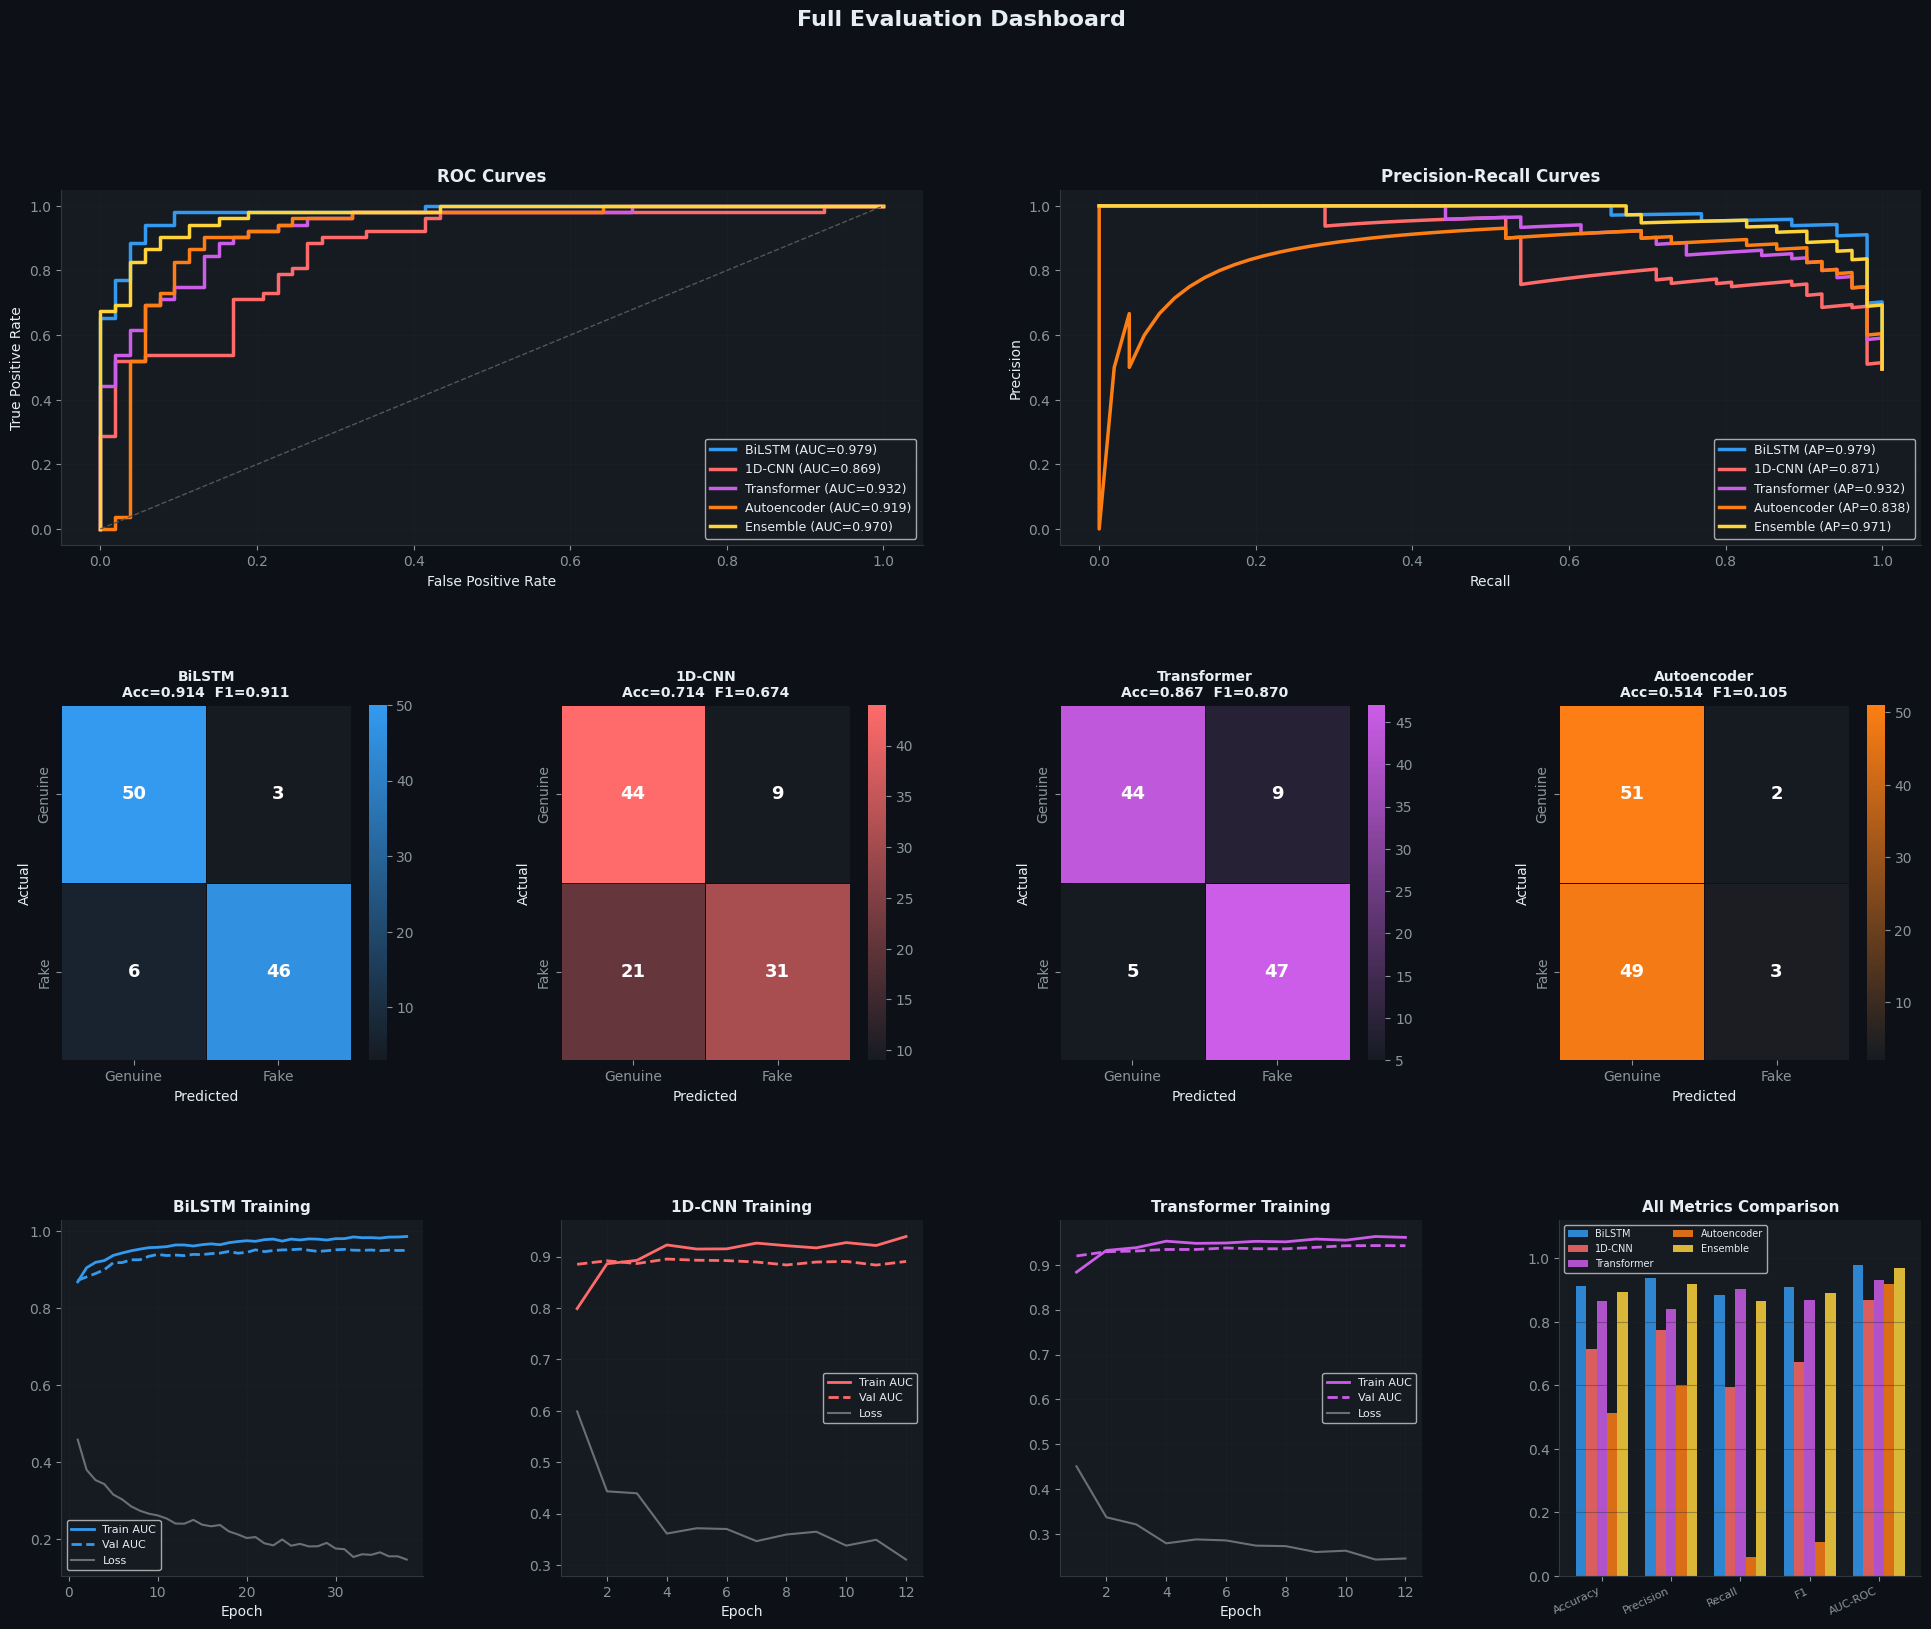

In [28]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle("Full Evaluation Dashboard", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(3, 4, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :2])
for (name, vals), color in zip(metrics.items(), PAL):
    ax1.plot(vals["fpr"], vals["tpr"], lw=2.5, color=color,
             label=f"{name} (AUC={vals['AUC-ROC']:.3f})")
ax1.plot([0,1],[0,1], "--", color="#555", lw=1)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves", fontweight="bold"); ax1.legend(fontsize=9); ax1.grid(alpha=0.35)

ax2 = fig.add_subplot(gs[0, 2:])
for (name, vals), color in zip(metrics.items(), PAL):
    ax2.plot(vals["rec_c"], vals["prc"], lw=2.5, color=color,
             label=f"{name} (AP={vals['AUC-PR']:.3f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.35)

single_models = ["BiLSTM", "1D-CNN", "Transformer", "Autoencoder"]
for i, (name, color) in enumerate(zip(single_models, PAL)):
    ax = fig.add_subplot(gs[1, i])
    proba, pred, _ = ALL_MODELS[name]
    cm_v = confusion_matrix(y_te, pred)
    cmap_cm = LinearSegmentedColormap.from_list("cm", ["#161b22", color])
    sns.heatmap(cm_v, annot=True, fmt="d", cmap=cmap_cm, ax=ax,
                linewidths=0.5, linecolor="#0d1117",
                xticklabels=["Genuine","Fake"], yticklabels=["Genuine","Fake"],
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"{name}\nAcc={accuracy_score(y_te,pred):.3f}  F1={f1_score(y_te,pred):.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

for i, (name, color) in enumerate(zip(["BiLSTM", "1D-CNN", "Transformer"], PAL)):
    ax = fig.add_subplot(gs[2, i])
    _, _, hist = ALL_MODELS[name]
    ep = range(1, len(hist.history["auc"])+1)
    ax.plot(ep, hist.history["auc"],     color=color, lw=2, label="Train AUC")
    ax.plot(ep, hist.history["val_auc"], color=color, lw=2, ls="--", label="Val AUC")
    ax.plot(ep, hist.history["loss"],    color="#8b949e", lw=1.5, alpha=0.7, label="Loss")
    ax.set_title(f"{name} Training", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.35)

ax_bar = fig.add_subplot(gs[2, 3])
metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
x = np.arange(len(metric_names))
w = 0.15
for i, (name, color) in enumerate(zip(ALL_MODELS.keys(), PAL)):
    vals = [metrics[name][m] for m in metric_names]
    ax_bar.bar(x + i*w, vals, w, label=name, color=color, alpha=0.85)
ax_bar.set_xticks(x + w*2)
ax_bar.set_xticklabels(metric_names, rotation=25, ha="right", fontsize=8)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_title("All Metrics Comparison", fontsize=11, fontweight="bold")
ax_bar.legend(fontsize=7, ncol=2); ax_bar.grid(axis="y", alpha=0.35)

plt.show()


## Inference on New Profiles

In [29]:
def predict_account(profile):
    raw = np.array([[
        profile.get("profile_pic", 0),
        profile.get("nums_length_username", 0),
        profile.get("fullname_words", 0),
        profile.get("nums_length_fullname", 0),
        profile.get("name_eq_username", 0),
        profile.get("description_length", 0),
        profile.get("external_url", 0),
        profile.get("private", 0),
        profile.get("posts", 0),
        profile.get("followers", 0),
        profile.get("follows", 0),
    ]], dtype=np.float32)

    flw, fwg, pst = raw[0, 9], raw[0, 10], raw[0, 8]
    extra = [[flw/(fwg+1), pst/(flw+1), raw[0,1]*raw[0,3],
              np.log1p(pst), np.log1p(flw), np.log1p(fwg)]]
    full   = np.concatenate([raw, extra], axis=1)
    sc     = scaler.transform(full).astype(np.float32)
    seq    = sc.reshape(1, N_FEAT, 1)

    p_lstm  = float(lstm_model.predict(seq, verbose=0)[0][0])
    p_cnn   = float(cnn_model.predict(seq, verbose=0)[0][0])
    p_trans = float(trans_model.predict(seq, verbose=0)[0][0])
    p_ae    = float(cls_model.predict(sc, verbose=0)[0][0])
    p_ens   = (p_lstm + p_cnn + p_trans + p_ae) / 4.0

    return {
        "BiLSTM":      round(p_lstm,  4),
        "1D-CNN":      round(p_cnn,   4),
        "Transformer": round(p_trans, 4),
        "Autoencoder": round(p_ae,    4),
        "Ensemble":    round(p_ens,   4),
        "Verdict":     "FAKE / SPAMMER" if p_ens >= 0.5 else "GENUINE",
    }

test_profiles = [
    {
        "name": "Classic bot",
        "profile_pic": 0, "nums_length_username": 0.65, "fullname_words": 0,
        "nums_length_fullname": 0, "name_eq_username": 1, "description_length": 0,
        "external_url": 1, "private": 0, "posts": 2, "followers": 38, "follows": 7200,
    },
    {
        "name": "Genuine user",
        "profile_pic": 1, "nums_length_username": 0.1, "fullname_words": 2,
        "nums_length_fullname": 0, "name_eq_username": 0, "description_length": 110,
        "external_url": 0, "private": 0, "posts": 190, "followers": 680, "follows": 310,
    },
    {
        "name": "Bought-followers fake",
        "profile_pic": 1, "nums_length_username": 0.25, "fullname_words": 1,
        "nums_length_fullname": 0, "name_eq_username": 0, "description_length": 18,
        "external_url": 1, "private": 0, "posts": 7, "followers": 45000, "follows": 85,
    },
]

print("-" * 60)
for p in test_profiles:
    result = predict_account(p)
    print(f"Profile: {p['name']}")
    for k, v in result.items():
        print(f"  {k:<14}: {v}")
    print("-" * 60)


------------------------------------------------------------
Profile: Classic bot
  BiLSTM        : 0.9233
  1D-CNN        : 0.5033
  Transformer   : 0.7584
  Autoencoder   : 0.7514
  Ensemble      : 0.7341
  Verdict       : FAKE / SPAMMER
------------------------------------------------------------
Profile: Genuine user
  BiLSTM        : 0.0115
  1D-CNN        : 0.4485
  Transformer   : 0.0915
  Autoencoder   : 0.2758
  Ensemble      : 0.2068
  Verdict       : GENUINE
------------------------------------------------------------
Profile: Bought-followers fake
  BiLSTM        : 0.0545
  1D-CNN        : 0.4607
  Transformer   : 0.1089
  Autoencoder   : 0.2377
  Ensemble      : 0.2155
  Verdict       : GENUINE
------------------------------------------------------------
